### Author
Created by Gleydson Martins

### Project Note
This project was developed to demonstrate data cleaning, exploratory data analysis,
business storytelling, feature engineering, and insight generation using Python.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio


# Configurações
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

# 1. Importing Dataset

In [11]:
df = pd.read_csv("../data/raw/Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## Data Understanding

The dataset contains transactional sales records from a fictional Superstore.
Each row represents an order line, including information about customer segment,
product category, sales, profit, discount, shipping mode, region, and order dates.

The purpose of this analysis is to identify the main drivers of sales and profitability,
with special attention to discounts, product categories, regional performance,
and shipping behavior.

# 2. Dataset Preliminary Diagnosis

In [12]:
df.shape

(9994, 21)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,"9,994.00",NaN,NaN,NaN,"4,997.50","2,885.16",1.00,"2,499.25","4,997.50","7,495.75","9,994.00"
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,9/5/2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.isna().sum().sort_values(ascending=False)


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# 3. Column Naming Standardization

In [16]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

# 4. Date Processing and Formatting

In [17]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

In [18]:
df[["order_date", "ship_date"]].isna().sum()

order_date    0
ship_date     0
dtype: int64

In [19]:
df["days_to_ship"] = (df["ship_date"] - df["order_date"]).dt.days

In [20]:
df[df["days_to_ship"] < 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,days_to_ship


In [21]:
df = df[df["days_to_ship"] >= 0]

# 5. Missing Data Handling

In [22]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missing["missing_pct"] = missing["missing_count"] / len(df) * 100
missing.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
row_id,0,0.00
order_id,0,0.00
order_date,0,0.00
ship_date,0,0.00
ship_mode,0,0.00
customer_id,0,0.00
customer_name,0,0.00
segment,0,0.00
country,0,0.00
city,0,0.00


In [23]:
df = df.drop(columns=["postal_code"], errors="ignore")

### Missing Values Treatment

The missing value analysis showed that postal code was not relevant for the business questions
addressed in this project. Since the analysis focuses on profitability, categories, regions,
shipping performance, and discount behavior, this column was removed from the analytical dataset.

# 6. Deduplication

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df = df.drop_duplicates()

# 7. Standardizing Categorical Variables

In [26]:
categorical_cols = [
    "ship_mode", "segment", "country", "city", "state",
    "region", "category", "sub_category"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [27]:
for col in ["ship_mode", "segment", "region", "category"]:
    print(col)
    print(df[col].unique())
    print("-" * 50)

ship_mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']
--------------------------------------------------
segment
['Consumer' 'Corporate' 'Home Office']
--------------------------------------------------
region
['South' 'West' 'Central' 'East']
--------------------------------------------------
category
['Furniture' 'Office Supplies' 'Technology']
--------------------------------------------------


# 8. Feature Engineering

## 8.1 Profit Margin

In [28]:
df["profit_margin"] = df["profit"] / df["sales"]

In [30]:
df["profit_margin"] = np.where(
    df["sales"] > 0,
    df["profit"] / df["sales"],
    np.nan
)

## 8.2 Discount Brackets 

In [31]:
def classify_discount(discount):
    if discount == 0:
        return "No discount"
    elif discount <= 0.10:
        return "Low discount"
    elif discount <= 0.30:
        return "Medium discount"
    else:
        return "High discount"

df["discount_tier"] = df["discount"].apply(classify_discount)

## 8.3 Year, month, and quarter

In [32]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_month_name"] = df["order_date"].dt.month_name()
df["order_quarter"] = df["order_date"].dt.to_period("Q").astype(str)
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)

## 8.4 Profitability Status

In [33]:
df["profit_status"] = np.where(df["profit"] >= 0, "Profitable", "Unprofitable")

# 9. Business-driven questions

## Business Questions

This EDA is guided by the following business questions:

1. Which product categories and sub-categories generate the highest sales and profit?
2. Are high sales always associated with high profit?
3. How do discounts affect profitability?
4. Which regions and customer segments are the most profitable?
5. Are there specific sub-categories destroying profit?
6. How does sales and profit performance evolve over time?
7. Does shipping speed or shipping mode affect profitability?
8. What business actions can improve profit margin?

# 10. Business-driven General KPIs

In [34]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
avg_profit_margin = df["profit"].sum() / df["sales"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()

kpis = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Average Profit Margin",
        "Total Orders",
        "Total Customers"
    ],
    "Value": [
        total_sales,
        total_profit,
        avg_profit_margin,
        total_orders,
        total_customers
    ]
})

kpis

,Metric,Value
0,Total Sales,"2,297,200.86"
1,Total Profit,"286,397.02"
2,Average Profit Margin,0.12
3,Total Orders,"5,009.00"
4,Total Customers,793.00


## Executive KPIs

The dataset shows the overall business size through total sales, total profit,
number of orders, and customer base. However, total sales alone are not enough
to evaluate business health. A high-sales business can still destroy value if
profit margins are low or if discounts are poorly managed.

# 11. Univariate Analysis

## 11.1 Sales Distribution

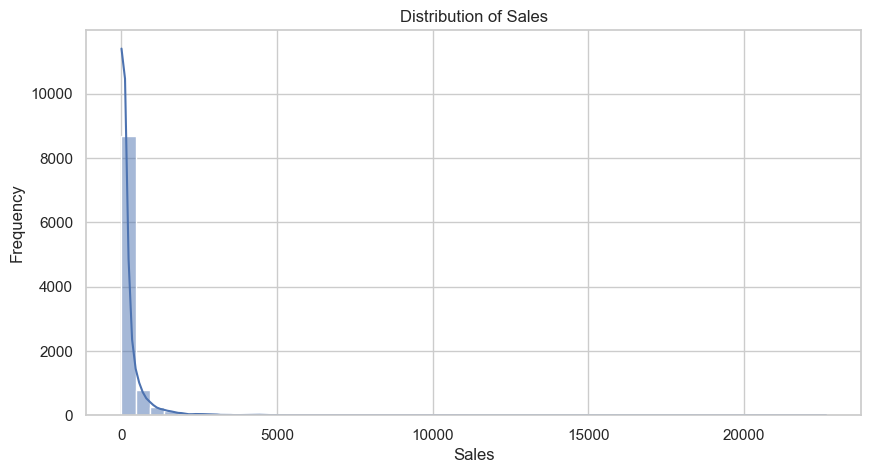

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df["sales"], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## 11.2 Profit Distribution

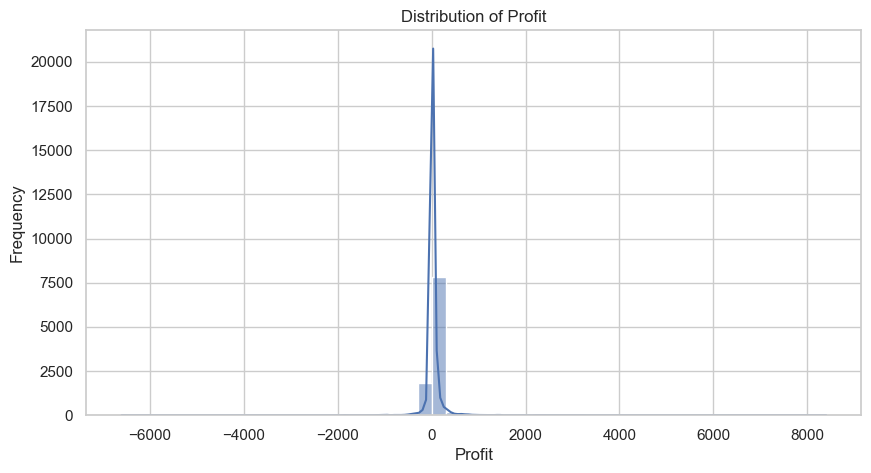

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(df["profit"], bins=50, kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()


## 11.3 Discount Distribution

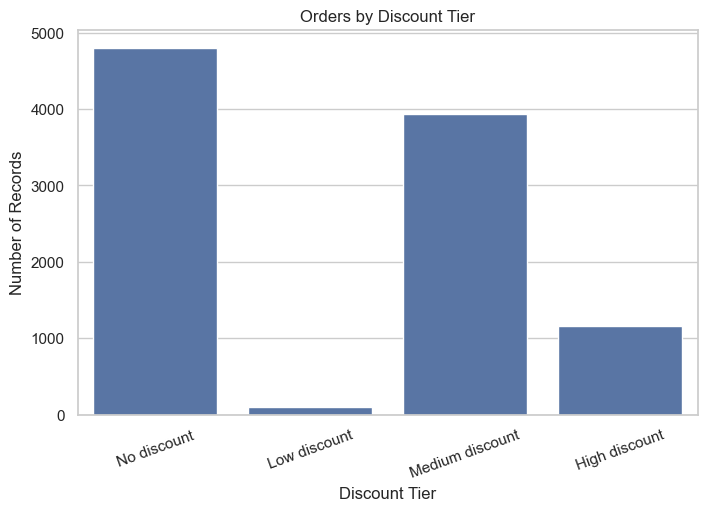

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="discount_tier", order=[
    "No discount", "Low discount", "Medium discount", "High discount"
])
plt.title("Orders by Discount Tier")
plt.xlabel("Discount Tier")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.show()


### Univariate Analysis

The sales and profit distributions are highly skewed, which is common in retail datasets.
Most transactions are small or medium-sized, while a few large transactions generate
disproportionate revenue. Profit also shows negative values, indicating that some
orders are unprofitable and require deeper investigation.

# 12. Analysis by Product Category

In [38]:
category_summary = (
    df.groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

category_summary["profit_margin"] = category_summary["profit"] / category_summary["sales"]

category_summary.sort_values("profit", ascending=False)

,category,sales,profit,quantity,avg_discount,profit_margin
2,Technology,"836,154.03","145,454.95",6939,0.13,0.17
1,Office Supplies,"719,047.03","122,490.80",22906,0.16,0.17
0,Furniture,"741,999.80","18,451.27",8028,0.17,0.02


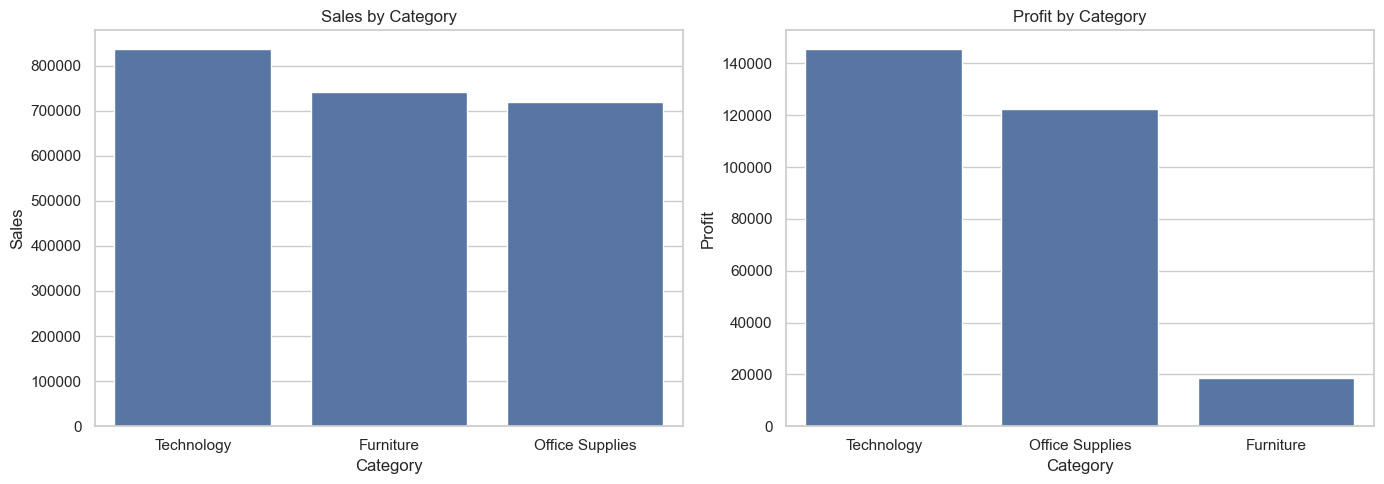

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=category_summary.sort_values("sales", ascending=False),
    x="category",
    y="sales",
    ax=ax[0]
)
ax[0].set_title("Sales by Category")
ax[0].set_xlabel("Category")
ax[0].set_ylabel("Sales")

sns.barplot(
    data=category_summary.sort_values("profit", ascending=False),
    x="category",
    y="profit",
    ax=ax[1]
)
ax[1].set_title("Profit by Category")
ax[1].set_xlabel("Category")
ax[1].set_ylabel("Profit")

plt.tight_layout()
plt.show()

### Category Performance

This analysis compares sales and profit by product category. The key business point
is to evaluate whether the categories generating the most revenue are also creating
the most profit. A gap between sales and profit may indicate excessive discounts,
high costs, or inefficient pricing strategies.


# 13. Subcategory Analysis by Product 

In [39]:
subcat_summary = (
    df.groupby("sub_category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

subcat_summary["profit_margin"] = subcat_summary["profit"] / subcat_summary["sales"]

subcat_summary = subcat_summary.sort_values("profit", ascending=True)

Text(0, 0.5, 'Sub-Category')

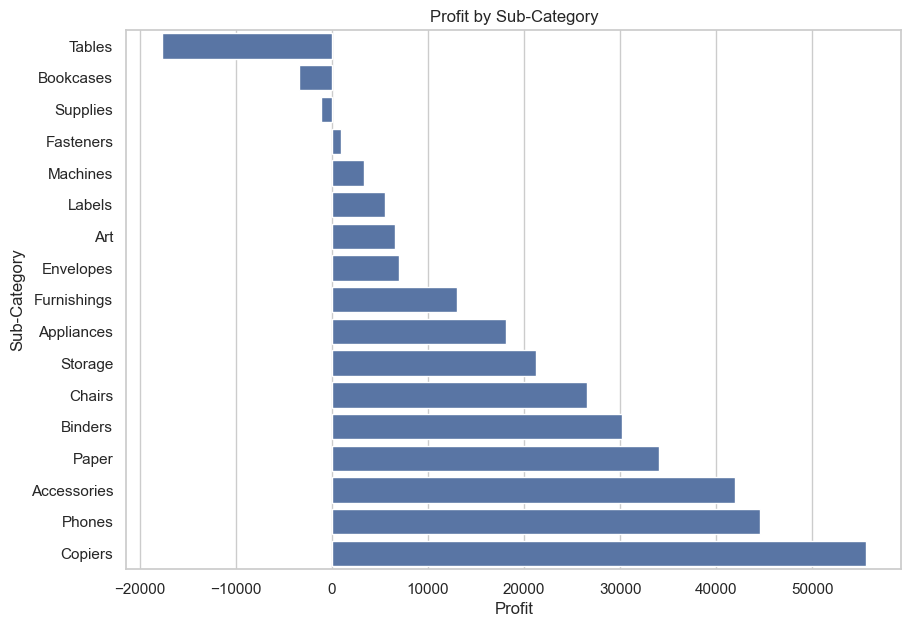

In [40]:
plt.figure(figsize=(10, 7))
sns.barplot(data=subcat_summary, y="sub_category", x="profit")
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")


### Sub-Category Profitability

The sub-category analysis helps identify profit drivers and profit destroyers.
This is more actionable than category-level analysis because business decisions
such as pricing, discount control, and assortment optimization are usually made
at a more granular product level.

Sub-categories with negative total profit should be reviewed carefully.
They may represent products with excessive discounting, low margins,
high operational cost, or poor pricing strategy.

# 14. Discount Impact on Profit Margins

In [41]:
discount_summary = (
    df.groupby("discount_tier")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_profit_margin=("profit_margin", "mean"),
        order_lines=("order_id", "count")
    )
    .reset_index()
)

discount_summary

,discount_tier,sales,profit,avg_profit_margin,order_lines
0,High discount,"259,543.49","-125,006.78",-0.91,1166
1,Low discount,"54,369.35","9,029.18",0.16,94
2,Medium discount,"895,379.54","81,387.02",0.16,3936
3,No discount,"1,087,908.47","320,987.60",0.34,4798


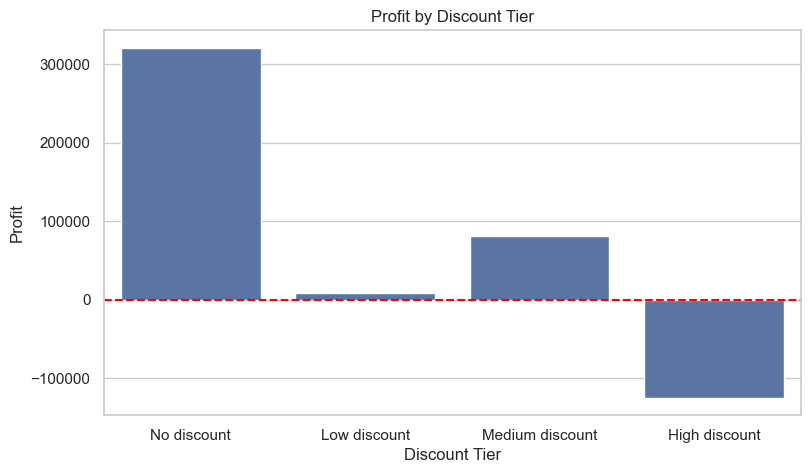

In [42]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=discount_summary,
    x="discount_tier",
    y="profit",
    order=["No discount", "Low discount", "Medium discount", "High discount"]
)
plt.title("Profit by Discount Tier")
plt.xlabel("Discount Tier")
plt.ylabel("Profit")
plt.axhline(0, color="red", linestyle="--")
plt.show()

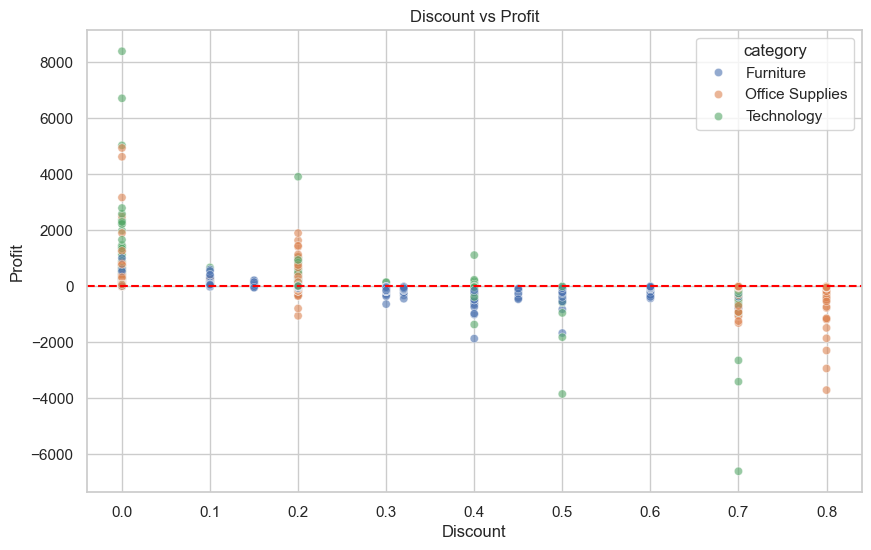

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    hue="category",
    alpha=0.6
)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.axhline(0, color="red", linestyle="--")
plt.show()

### Discount Impact

Discounts are one of the most important profitability levers in retail.
The analysis evaluates whether discounts are helping the company increase profitable
sales or whether they are eroding margins and generating unprofitable transactions.

A discount strategy should not be judged only by revenue growth. Higher sales volume
only creates value when it compensates for the reduction in profit margin. Therefore,
this section analyzes sales, profit, and profit margin across discount tiers to
understand whether discounts are being used strategically.

If high discount levels are associated with lower or negative profit, the company
should review its promotional strategy and implement discount limits by category,
sub-category, or customer segment.

# 15. Analysis by Region and Customer Segment

## 15.1 Region

In [44]:
region_summary = (
    df.groupby("region")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_profit_margin=("profit_margin", "mean"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

region_summary.sort_values("profit", ascending=False)

,region,sales,profit,avg_profit_margin,avg_discount
3,West,"725,457.82","108,418.45",0.22,0.11
1,East,"678,781.24","91,522.78",0.17,0.15
2,South,"391,721.91","46,749.43",0.16,0.15
0,Central,"501,239.89","39,706.36",-0.10,0.24


Text(0, 0.5, 'Profit')

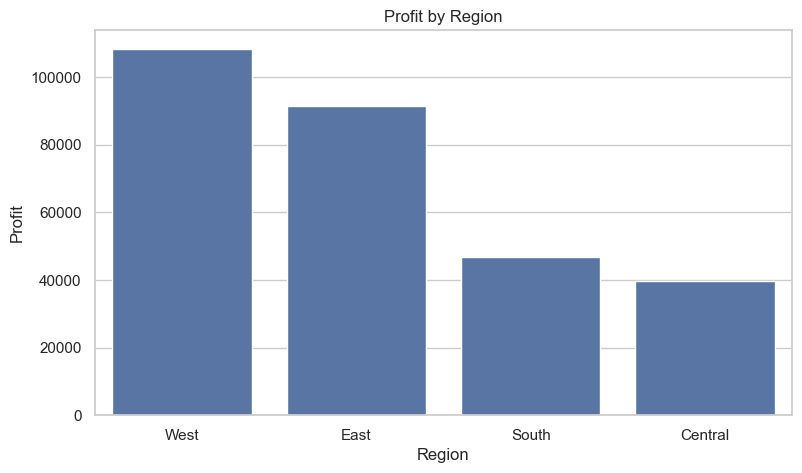

In [45]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=region_summary.sort_values("profit", ascending=False),
    x="region",
    y="profit"
)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")


## 15.2 Segment

In [46]:
segment_summary = (
    df
    .groupby("segment", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
        avg_discount=("discount", "mean")
    )
    .assign(
        profit_margin=lambda x: x["profit"] / x["sales"]
    )
    .sort_values(by="profit", ascending=False)
)

segment_summary[[
    "sales",
    "profit",
    "avg_discount",
    "profit_margin"
]] = segment_summary[[
    "sales",
    "profit",
    "avg_discount",
    "profit_margin"
]].round(2)

segment_summary


,segment,sales,profit,quantity,orders,customers,avg_discount,profit_margin
0,Consumer,"1,161,401.34","134,119.21",19521,2586,409,0.16,0.12
1,Corporate,"706,146.37","91,979.13",11608,1514,236,0.16,0.13
2,Home Office,"429,653.15","60,298.68",6744,909,148,0.15,0.14


<function matplotlib.pyplot.show(close=None, block=None)>

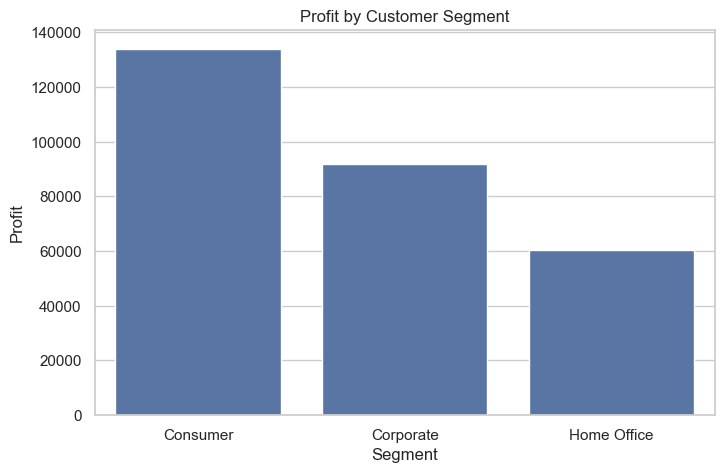

In [47]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=segment_summary.sort_values("profit", ascending=False),
    x="segment",
    y="profit"
)
plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.show

### Regional and Segment Performance

Regional and customer segment analysis helps identify where the company is creating
or losing value. Regions with high sales but weak profit margins may require
pricing review, discount control, or product mix optimization.

Customer segments should also be evaluated beyond revenue.

# 16. Time-based Analysis

In [48]:
monthly_summary = (
    df.groupby("year_month")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

monthly_summary["year_month"] = pd.to_datetime(monthly_summary["year_month"])

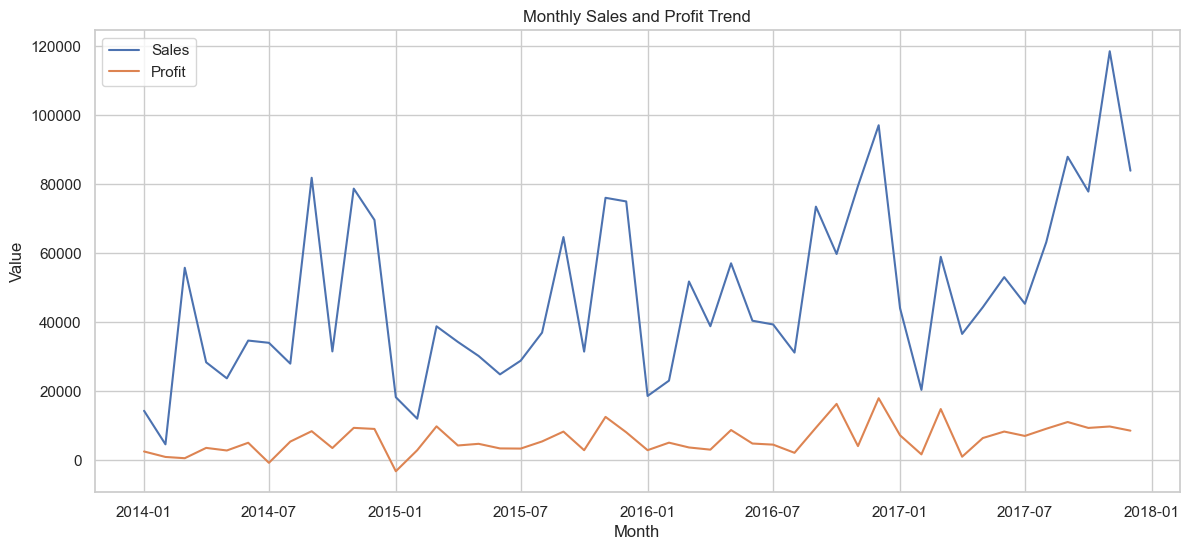

In [49]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_summary, x="year_month", y="sales", label="Sales")
sns.lineplot(data=monthly_summary, x="year_month", y="profit", label="Profit")
plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.show()

In [50]:
import plotly.express as px
fig = px.line(
    monthly_summary,
    x="year_month",
    y=["sales", "profit"],
    title="Monthly Sales and Profit Trend"
)

fig.show()

### Time Series Analysis

The temporal analysis helps identify seasonality, growth patterns, and periods of
profit deterioration. Comparing sales and profit over time is especially important
because revenue growth without profit growth may indicate margin compression.

# 17. Shipping Analysis

In [51]:
ship_summary = (
    df.groupby("ship_mode")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_days_to_ship=("days_to_ship", "mean"),
        avg_profit_margin=("profit_margin", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

ship_summary.sort_values("profit", ascending=False)

,ship_mode,sales,profit,avg_days_to_ship,avg_profit_margin,orders
3,Standard Class,"1,358,215.74","164,088.79",5.01,0.11,2994
2,Second Class,"459,193.57","57,446.64",3.24,0.15,964
0,First Class,"351,428.42","48,969.84",2.18,0.12,787
1,Same Day,"128,363.12","15,891.76",0.04,0.14,264


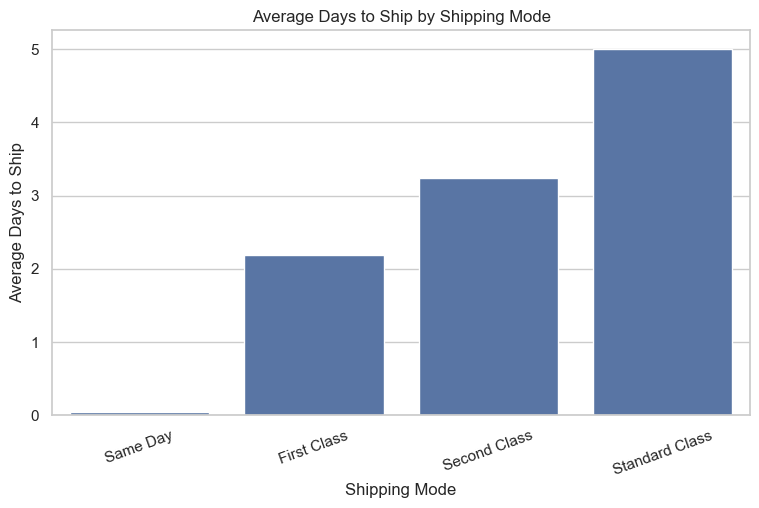

In [54]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=ship_summary.sort_values("avg_days_to_ship"),
    x="ship_mode",
    y="avg_days_to_ship"
)
plt.title("Average Days to Ship by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Days to Ship")
plt.xticks(rotation=20)
plt.show()

### Shipping Performance

Shipping mode analysis evaluates operational efficiency and its relationship with
profitability. Faster shipping is not always better from a business perspective
if it reduces margins or increases operational costs. The goal is to identify
whether specific shipping modes are associated with lower profit margins.

# 18. Outliers

In [55]:
numeric_cols = ["sales", "quantity", "discount", "profit", "profit_margin", "days_to_ship"]

df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
sales,"9,994.00",229.86,623.25,0.44,2.29,4.98,17.28,54.49,209.94,956.98,"2,481.69","22,638.48"
quantity,"9,994.00",3.79,2.23,1.00,1.00,1.00,2.00,3.00,5.00,8.00,11.00,14.00
discount,"9,994.00",0.16,0.21,0.00,0.00,0.00,0.00,0.20,0.20,0.70,0.80,0.80
profit,"9,994.00",28.66,234.26,"-6,599.98",-319.26,-53.03,1.73,8.67,29.36,168.47,580.66,"8,399.98"
profit_margin,"9,994.00",0.12,0.47,-2.75,-1.75,-0.77,0.07,0.27,0.36,0.48,0.50,0.50
days_to_ship,"9,994.00",3.96,1.75,0.00,0.00,0.00,3.00,4.00,5.00,7.00,7.00,7.00


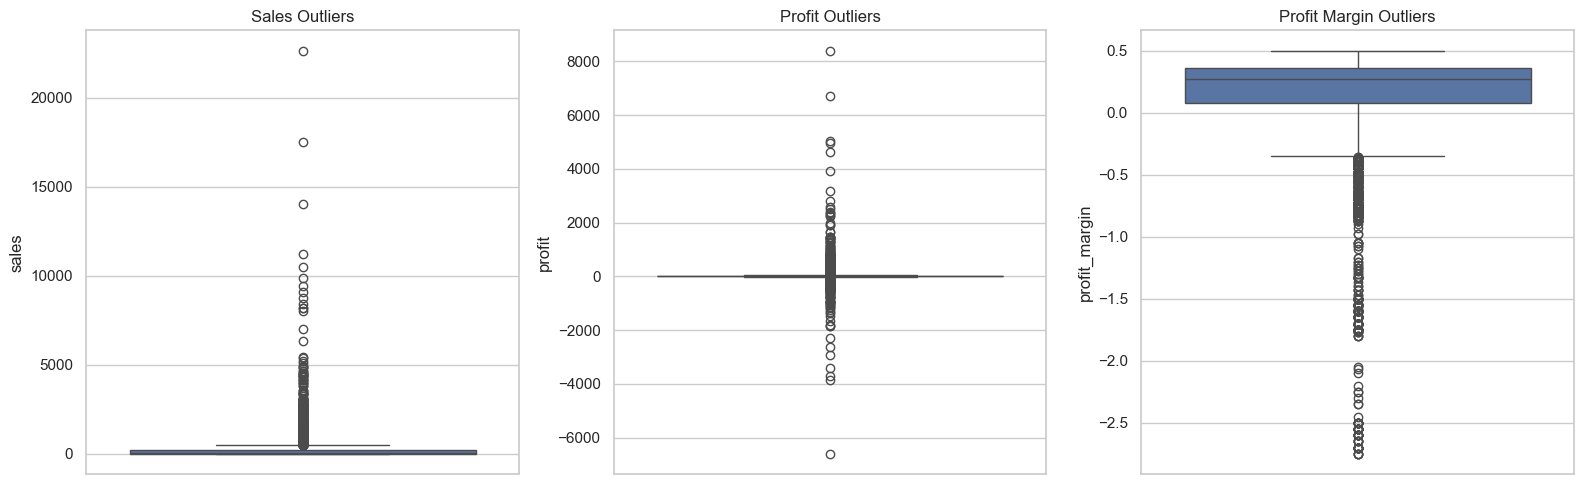

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, y="sales", ax=axes[0])
axes[0].set_title("Sales Outliers")

sns.boxplot(data=df, y="profit", ax=axes[1])
axes[1].set_title("Profit Outliers")

sns.boxplot(data=df, y="profit_margin", ax=axes[2])
axes[2].set_title("Profit Margin Outliers")

plt.tight_layout()
plt.show()

### Outlier Treatment

Outliers were not removed automatically because extreme values may represent
real and strategically important transactions, such as large corporate orders
or heavily discounted loss-making sales.

Instead of deleting them, the analysis uses outliers as business signals:
- unusually high sales may indicate key accounts or bulk purchases;
- highly negative profit may reveal problematic discounting or pricing;
- extreme margins may indicate data quality issues or exceptional transactions.

# 19. Insigts and Recomendations

In [58]:
pd.set_option("display.max_colwidth", None)

insights = pd.DataFrame({
    "Insight": [
        "Some sub-categories generate negative profit despite having sales volume.",
        "High discount tiers are associated with weaker profitability.",
        "Sales and profit do not always move together.",
        "Regional profitability varies significantly.",
        "Shipping mode should be evaluated not only by speed but also by margin."
    ],
    "Business Recommendation": [
        "Review pricing, supplier cost, and discount policy for unprofitable sub-categories.",
        "Implement discount thresholds by category and require approval for high discounts.",
        "Use profit margin as a core KPI, not only sales volume.",
        "Investigate regional pricing, demand mix, and promotional policies.",
        "Balance customer service level with shipping cost and profitability."
    ]
})

insights

,Insight,Business Recommendation
0,Some sub-categories generate negative profit despite having sales volume.,"Review pricing, supplier cost, and discount policy for unprofitable sub-categories."
1,High discount tiers are associated with weaker profitability.,Implement discount thresholds by category and require approval for high discounts.
2,Sales and profit do not always move together.,"Use profit margin as a core KPI, not only sales volume."
3,Regional profitability varies significantly.,"Investigate regional pricing, demand mix, and promotional policies."
4,Shipping mode should be evaluated not only by speed but also by margin.,Balance customer service level with shipping cost and profitability.


# 20. Saving Cleaned Dataset

In [59]:
df.to_csv("../data/processed/superstore_clean.csv", index=False)

# Final Business Recommendations

Based on the exploratory analysis, the Superstore should focus on profitability
management rather than only revenue growth.

### Recommendation 1: Control high discounts
High discount levels appear to be strongly associated with lower profitability.
The company should define discount limits by category and sub-category.

### Recommendation 2: Review unprofitable sub-categories
Some sub-categories may be destroying value. These products should be reviewed
for pricing, supplier costs, promotional strategy, and inventory decisions.

### Recommendation 3: Monitor profit margin as a primary KPI
Sales volume alone can be misleading. Profit margin should be tracked by region,
segment, category, and sub-category.

### Recommendation 4: Optimize regional strategy
Regions with high sales but weak profits should be investigated to understand
whether the issue is discounting, product mix, or operational cost.

### Recommendation 5: Evaluate shipping modes from a margin perspective
Shipping strategy should balance delivery speed, customer experience, and profitability.

## To Do Next

If this were a real business project, the next steps would be:

1. Build a profitability dashboard in Power BI or Metabase.
2. Create a predictive model to estimate profit risk before applying discounts.
3. Analyze customer lifetime value by segment.
4. Investigate whether shipping cost data explains low-margin orders.
5. Design an A/B test for discount policy optimization.